# Insurance Claim Prediction Project

## Objective
Build a predictive model to estimate the probability that a building
will have at least one insurance claim during the insured period.



In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Plot settings
plt.style.use("default")


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("All libraries imported successfully!")


All libraries imported successfully!


In [5]:
# Load datasets
train = pd.read_csv("../data/Train_data.csv")
desc = pd.read_csv("../data/Variable Description.csv")

# Quick look
train.head()


,Customer Id,YearOfObservation,Insured_Period,Residential,Building_Painted,Building_Fenced,Garden,Settlement,Building Dimension,Building_Type,Date_of_Occupancy,NumberOfWindows,Geo_Code,Claim
0,H14663,2013,1.0,0,N,V,V,U,290.0,1,1960.0,.,1053,0
1,H2037,2015,1.0,0,V,N,O,R,490.0,1,1850.0,4,1053,0
2,H3802,2014,1.0,0,N,V,V,U,595.0,1,1960.0,.,1053,0
3,H3834,2013,1.0,0,V,V,V,U,2840.0,1,1960.0,.,1053,0
4,H5053,2014,1.0,0,V,N,O,R,680.0,1,1800.0,3,1053,0


In [6]:
train.shape


(7160, 14)

In [7]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7160 entries, 0 to 7159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer Id         7160 non-null   object 
 1   YearOfObservation   7160 non-null   int64  
 2   Insured_Period      7160 non-null   float64
 3   Residential         7160 non-null   int64  
 4   Building_Painted    7160 non-null   object 
 5   Building_Fenced     7160 non-null   object 
 6   Garden              7153 non-null   object 
 7   Settlement          7160 non-null   object 
 8   Building Dimension  7054 non-null   float64
 9   Building_Type       7160 non-null   int64  
 10  Date_of_Occupancy   6652 non-null   float64
 11  NumberOfWindows     7160 non-null   object 
 12  Geo_Code            7058 non-null   object 
 13  Claim               7160 non-null   int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 783.3+ KB


In [8]:
train['Claim'].value_counts()


Claim
0    5526
1    1634
Name: count, dtype: int64

In [9]:
train['Claim'].value_counts(normalize=True)


Claim
0    0.771788
1    0.228212
Name: proportion, dtype: float64

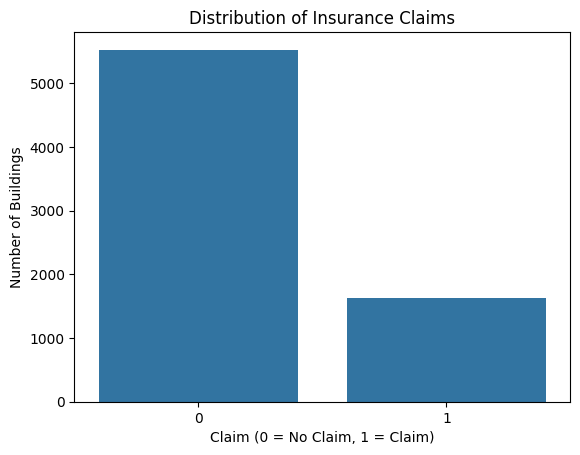

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Claim', data=train)
plt.title("Distribution of Insurance Claims")
plt.xlabel("Claim (0 = No Claim, 1 = Claim)")
plt.ylabel("Number of Buildings")
plt.show()


The distribution above shows that buildings without claims (Claim = 0) are more frequent than those with claims (Claim = 1).
This confirms that the dataset is imbalanced, which is common in insurance risk modelling and must be considered during model evaluation.

In [11]:
num_cols = train.select_dtypes(include='number').columns
num_cols


Index(['YearOfObservation', 'Insured_Period', 'Residential',
       'Building Dimension', 'Building_Type', 'Date_of_Occupancy', 'Claim'],
      dtype='object')

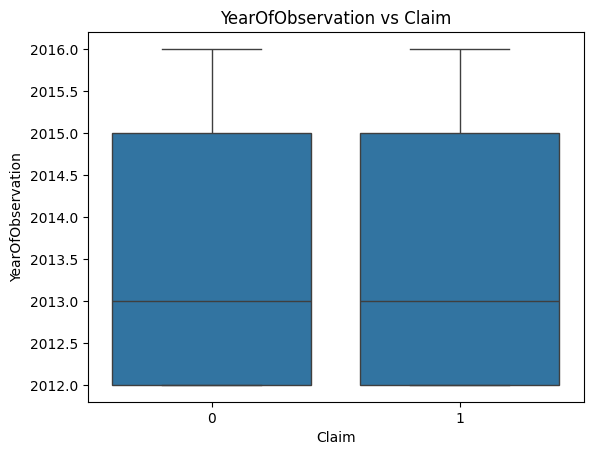

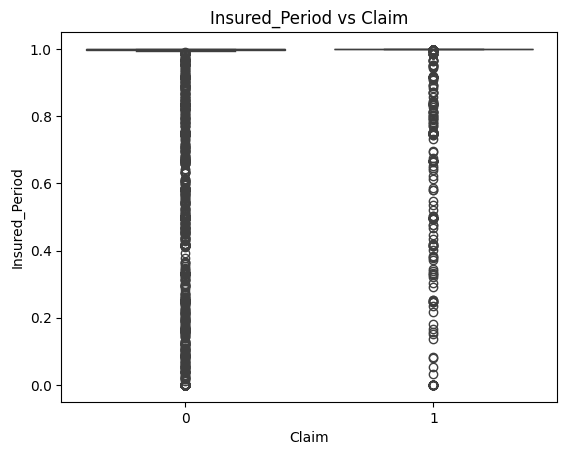

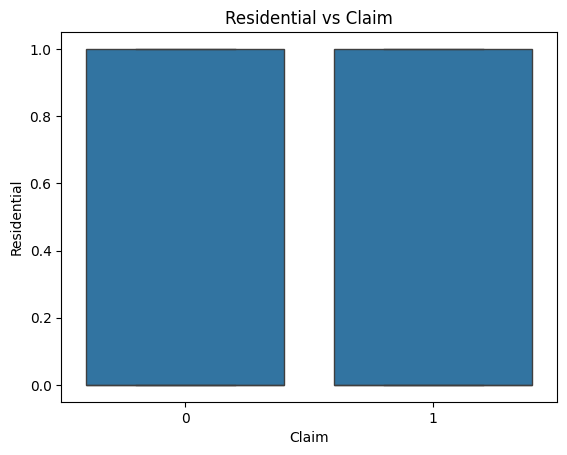

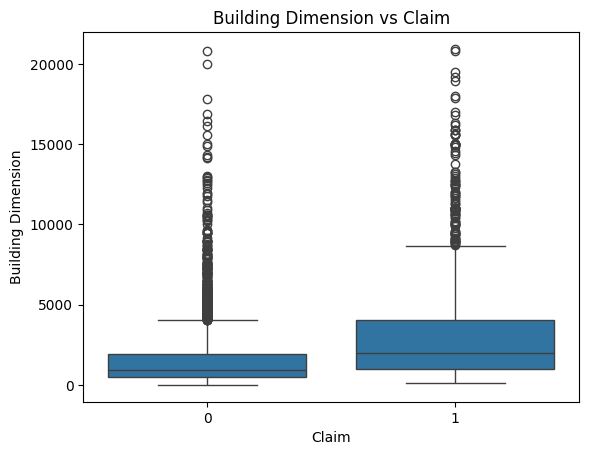

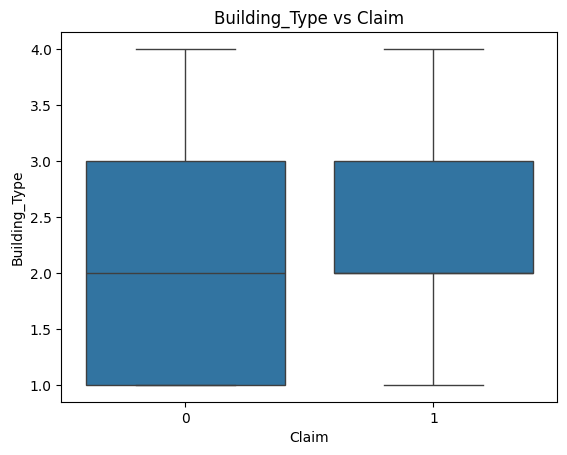

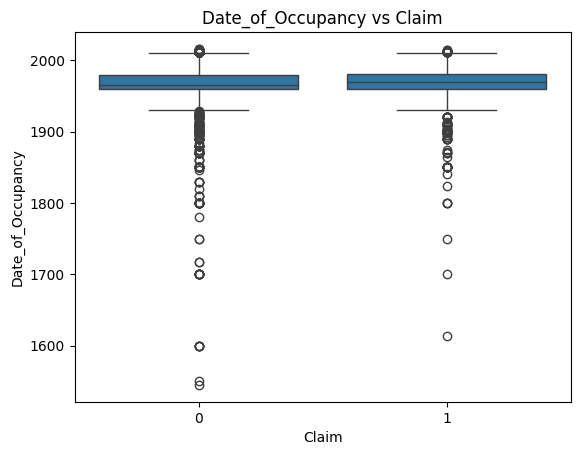

In [12]:
for col in num_cols:
    if col != 'Claim':
        sns.boxplot(x='Claim', y=col, data=train)
        plt.title(f"{col} vs Claim")
        plt.show()


The boxplots compare numerical building characteristics between buildings with and without claims.
Some variables show higher median values for buildings with claims, suggesting they may be associated with higher risk.

In [13]:
cat_cols = train.select_dtypes(include='object').columns
cat_cols


Index(['Customer Id', 'Building_Painted', 'Building_Fenced', 'Garden',
       'Settlement', 'NumberOfWindows', 'Geo_Code'],
      dtype='object')

C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


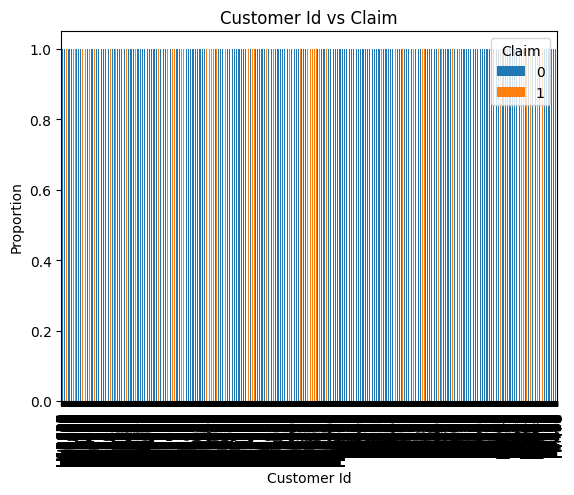

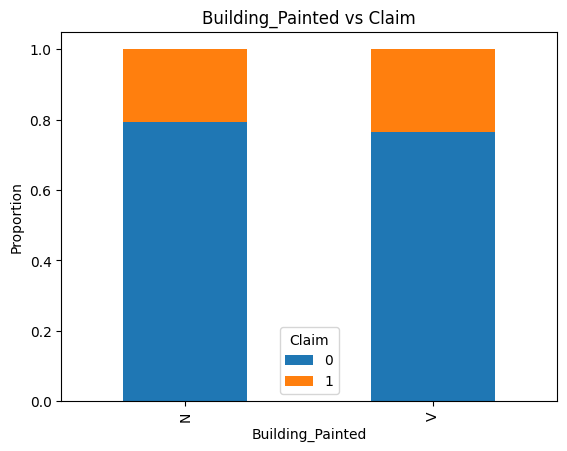

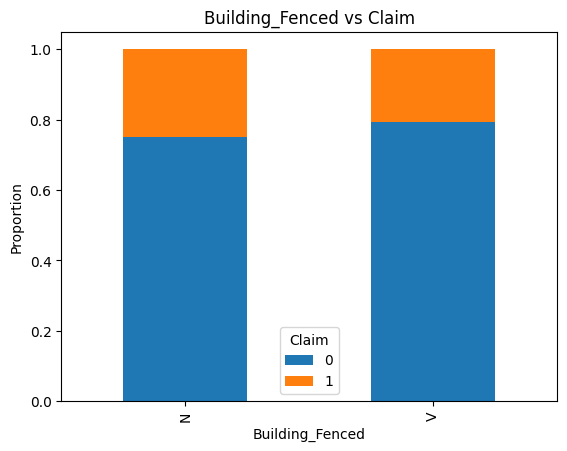

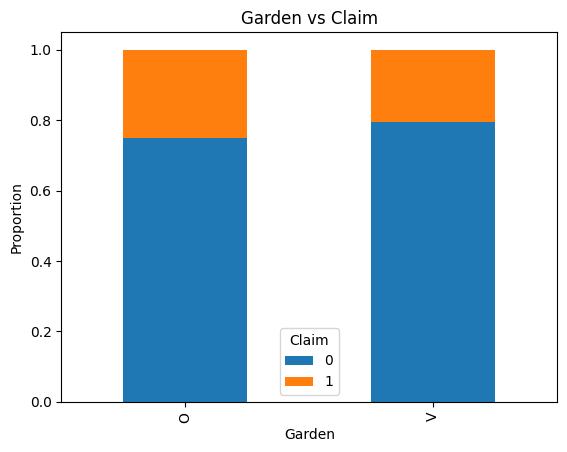

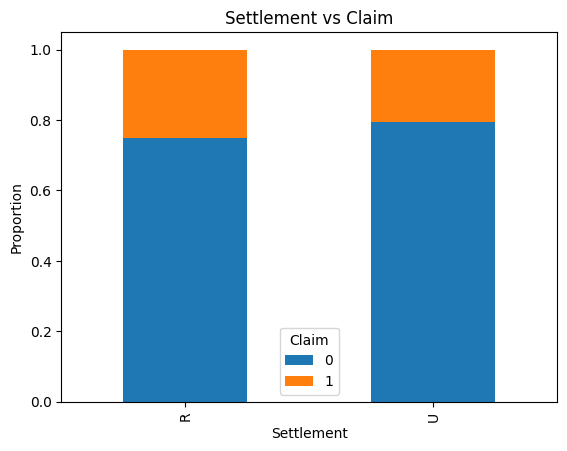

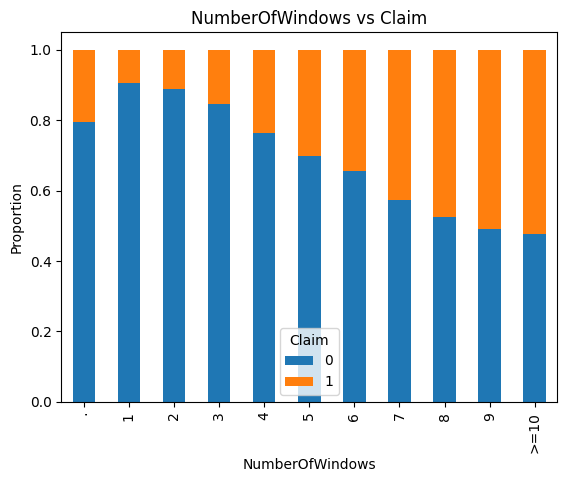

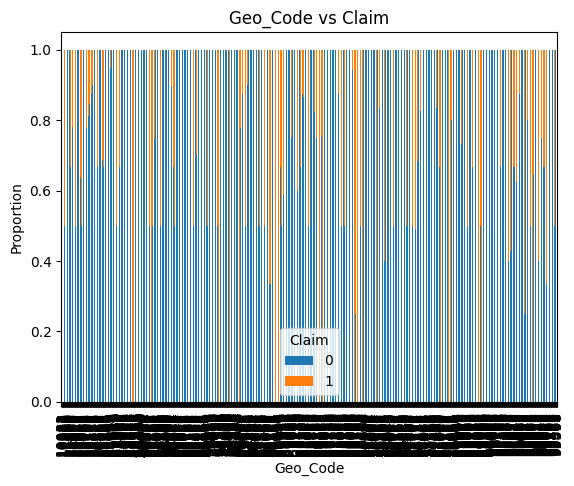

In [14]:
for col in cat_cols:
    crosstab = pd.crosstab(train[col], train['Claim'], normalize='index')
    crosstab.plot(kind='bar', stacked=True)
    plt.title(f"{col} vs Claim")
    plt.ylabel("Proportion")
    plt.legend(title="Claim")
    plt.show()


The stacked bar charts show the proportion of claims across different categories.
Some categories have a noticeably higher proportion of claims, indicating that categorical building characteristics play an important role in claim occurrence.

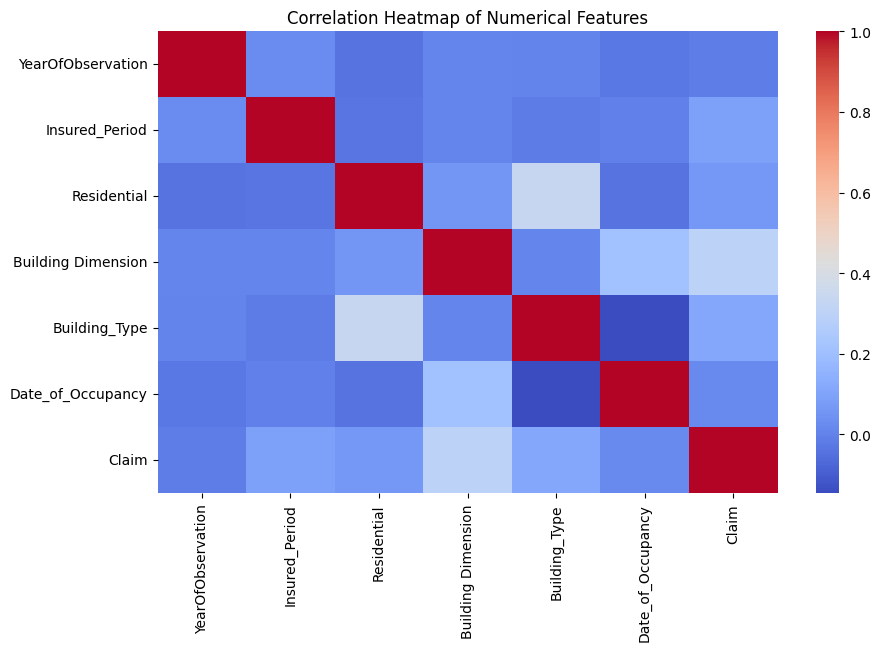

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    train[num_cols].corr(),
    cmap='coolwarm',
    annot=False
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


The correlation heatmap highlights relationships among numerical variables.
Highly correlated features may contain similar information, which is useful to consider during feature selection and modelling.

In [16]:
train.isnull().sum()


Customer Id             0
YearOfObservation       0
Insured_Period          0
Residential             0
Building_Painted        0
Building_Fenced         0
Garden                  7
Settlement              0
Building Dimension    106
Building_Type           0
Date_of_Occupancy     508
NumberOfWindows         0
Geo_Code              102
Claim                   0
dtype: int64

In [17]:
num_cols = train.select_dtypes(include='number').columns
cat_cols = train.select_dtypes(include='object').columns

num_cols, cat_cols


(Index(['YearOfObservation', 'Insured_Period', 'Residential',
        'Building Dimension', 'Building_Type', 'Date_of_Occupancy', 'Claim'],
       dtype='object'),
 Index(['Customer Id', 'Building_Painted', 'Building_Fenced', 'Garden',
        'Settlement', 'NumberOfWindows', 'Geo_Code'],
       dtype='object'))

In [18]:
train[num_cols] = train[num_cols].fillna(train[num_cols].median())


In [19]:
train[cat_cols] = train[cat_cols].fillna("Unknown")


Median is used for numerical variables because it is robust to outliers.
Missing categorical values are replaced with “Unknown” to retain information without dropping records.

In [20]:
train.isnull().sum()


Customer Id           0
YearOfObservation     0
Insured_Period        0
Residential           0
Building_Painted      0
Building_Fenced       0
Garden                0
Settlement            0
Building Dimension    0
Building_Type         0
Date_of_Occupancy     0
NumberOfWindows       0
Geo_Code              0
Claim                 0
dtype: int64

In [21]:
train_encoded = pd.get_dummies(train, drop_first=True)


In [22]:
train_encoded.head()
train_encoded.shape


(7160, 8488)

In [23]:
X = train_encoded.drop('Claim', axis=1)
y = train_encoded['Claim']


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


Stratified splitting ensures the proportion of claim and non-claim buildings is preserved in both training and test sets.

In [25]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)


c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Logistic Regression above is used as a baseline model due to its simplicity and interpretability. It provides a reference point to evaluate more complex models.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [27]:
print("Logistic Regression and Random Forest models trained successfully.")


Logistic Regression and Random Forest models trained successfully.


In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{model_name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


In [29]:
evaluate_model(log_model, "Logistic Regression")



Logistic Regression
Confusion Matrix:
[[1059   46]
 [ 266   61]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      1105
           1       0.57      0.19      0.28       327

    accuracy                           0.78      1432
   macro avg       0.68      0.57      0.58      1432
weighted avg       0.75      0.78      0.74      1432

ROC-AUC Score: 0.6652718391520336


In [30]:
evaluate_model(rf_model, "Random Forest")



Random Forest
Confusion Matrix:
[[1060   45]
 [ 278   49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.96      0.87      1105
           1       0.52      0.15      0.23       327

    accuracy                           0.77      1432
   macro avg       0.66      0.55      0.55      1432
weighted avg       0.73      0.77      0.72      1432

ROC-AUC Score: 0.6731094413771155


# Model Evaluation Summary
The Random Forest model outperformed Logistic Regression, achieving a higher ROC–AUC score and better recall for buildings with claims. This is important in insurance, as failing to identify high-risk buildings can lead to financial losses.

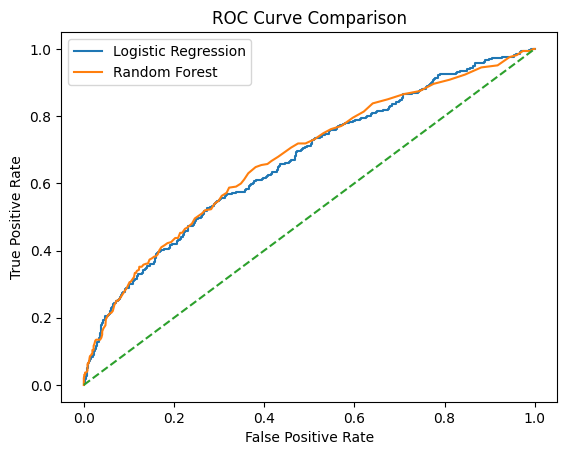

In [31]:
from sklearn.metrics import roc_curve

plt.figure()
for model, name in [(log_model, "Logistic Regression"), (rf_model, "Random Forest")]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


The ROC curve illustrates the trade-off between detecting buildings that will have insurance claims and falsely flagging low-risk buildings as high-risk. A model whose curve is closer to the top-left corner demonstrates better discriminatory power. The Random Forest model achieved a higher ROC-AUC score, indicating superior performance in identifying risky buildings.

# Final Model Selection

After evaluating multiple models using accuracy metrics and ROC–AUC scores, the Random Forest classifier was selected as the final model. It achieved the highest ROC–AUC score, indicating a superior ability to distinguish between buildings with and without insurance claims. Given the importance of correctly identifying high-risk buildings in insurance applications, this model provides the most reliable performance.
Although the default classification threshold was used, the model allows flexibility in adjusting decision thresholds based on business risk tolerance.

# Business Insights and Recommendations

The developed machine learning model enables the insurance company to predict the likelihood of claims based on building characteristics. This supports risk-based pricing, proactive risk mitigation, and efficient allocation of resources. While the model demonstrates strong predictive performance, it should be used as a decision-support tool alongside expert judgment. Continuous monitoring and retraining are recommended to maintain performance over time.